In [27]:
import nltk
from nltk.downloader import download

# Download the required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Required for newer versions of NLTK tokenization

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
# Cell 1: Comprehensive Imports
import warnings, re, os, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud


from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

Environment ready ✓


In [65]:
# Cell 2: Configurable Scraper Function
import numbers
from google_play_scraper import reviews, Sort

# App package IDs for global fintech apps
APPS = {
    'BOA' : 'com.boa.boaMobileBanking',
    'CBE' : 'com.combanketh.mobilebanking',
    'Dashen' : 'com.dashen.dashensuperapp'
}
bank_id_map = {name: i + 1 for i, name in enumerate(APPS.keys())}

def scrape_fintech_reviews(app_dict, count=200):
    """Fetches recent reviews for a dictionary of apps."""
    all_reviews = []
    for name, pkg in app_dict.items():
        try:
            current_bank_id = bank_id_map[name] 
            res, _ = reviews(pkg, lang='en', country='et', sort=Sort.NEWEST, count=count)
            for r in res:
                all_reviews.append({
                    'bank_id' : current_bank_id,
                    'bank_name': name,
                    'app': name,
                    'review': r['content'],
                    'rating': r['score'],
                    'date': r['at'],
                    'thumbs': r['thumbsUpCount']
                })
            print(f"  Scraped {len(res)} reviews for {name}")
        except Exception as e:
            print(f"  Failed to scrape {name}: {e}")
    return pd.DataFrame(all_reviews)

# Fetching reviews
df_raw = scrape_fintech_reviews(APPS, count=500 )
print(f"\nTotal raw reviews: {len(df_raw)}")

  Scraped 500 reviews for BOA
  Scraped 500 reviews for CBE
  Scraped 500 reviews for Dashen

Total raw reviews: 1500


In [59]:
# Create a unique list of banks and assign an ID to each
unique_banks = df_clean['bank_name'].unique()
bank_mapping = {name: i + 1 for i, name in enumerate(unique_banks)}

# Apply the mapping to the bank_id column
df_clean['bank_id'] = df_clean['bank_name'].map(bank_mapping)

# Verify the change
print(df_clean[['bank_id', 'bank_name']].drop_duplicates())

     bank_id bank_name
0          1       BOA
492        2       CBE
969        3    Dashen


In [66]:
# Cell 3: Preprocessing Logic
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 1389


In [67]:
# Cell 3: Robust Cleaning & Normalisation
def robust_clean(df):
    # 1. Strip Whitespaces & Trailing Zeros
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace(r'\.0$', '', regex=True)

    # 2. Date Normalisation
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')

    # 3. Handle Missing Values
    print(f"Nulls before: {df.isnull().sum().sum()}")
    df = df.dropna(subset=['review', 'rating'])

    # 4. Filter empty/short reviews
    df = df[df['review'].str.len() > 2]

    print(f"Final Nulls: {df.isnull().sum().sum()}")
    print(f"Final Dataset Shape: {df.shape}")
    return df.reset_index(drop=True)

df_clean = robust_clean(df_raw.copy())

Nulls before: 0
Final Nulls: 0
Final Dataset Shape: (1458, 8)


In [68]:
import os

# 1. Ensure the directory exists
output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)

# 2. Define the file path
# It's helpful to include 'cleaned' in the name to distinguish it from raw data
output_path = os.path.join(output_dir, "cleaned_bank_reviews.csv")

# 3. Export to CSV
# index=False prevents pandas from adding an extra 'unnamed: 0' column
# encoding='utf-8-sig' ensures emojis and special characters display correctly
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Export Complete! File saved to: {output_path}")
print(f"Total rows exported: {len(df_clean)}")

Export Complete! File saved to: data/processed\cleaned_bank_reviews.csv
Total rows exported: 1458


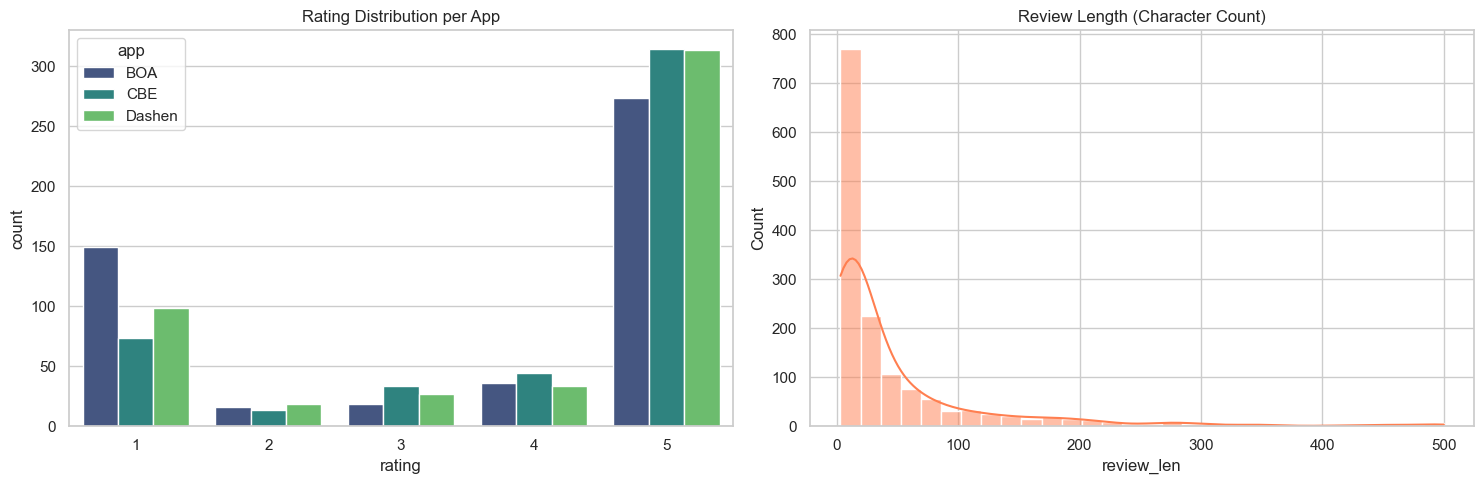

In [32]:
# Cell 4: Visualizing Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df_clean, x='rating', hue='app', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

## 2. Sentiment Model Comparison: VADER, TextBlob, and Transformer

In [33]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.60
neutral     0.26
negative    0.14
Name: proportion, dtype: float64


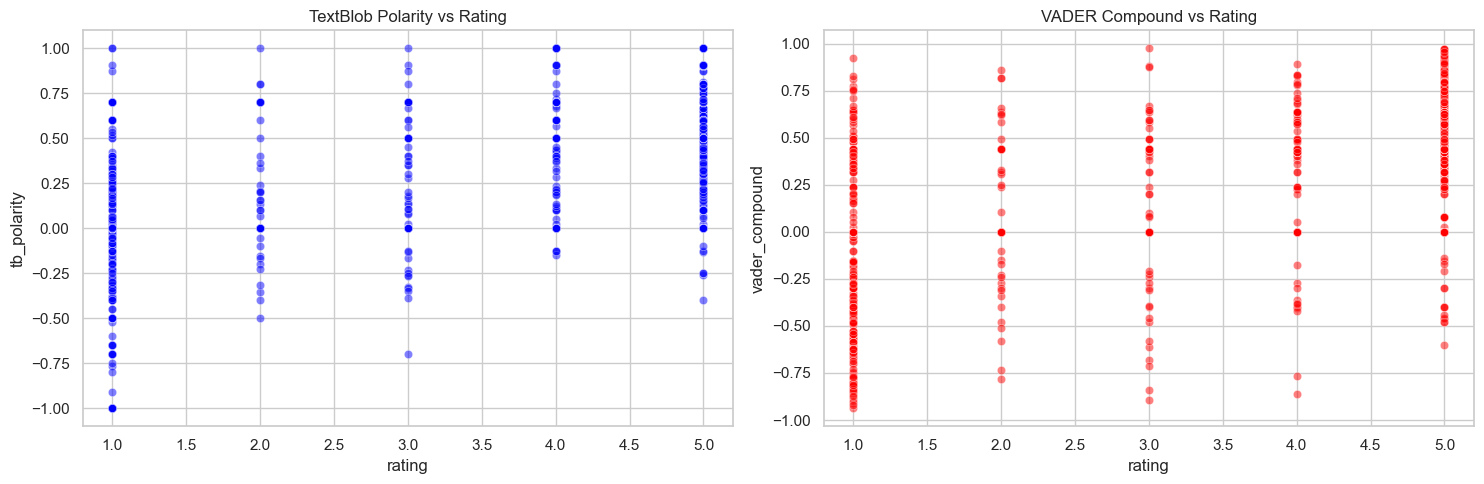

In [34]:
# Sentiment vs. Star Rating
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='rating', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

In [35]:
# Cell 11: Transformer Pipeline
from tqdm import tqdm

try:
    from transformers import pipeline
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Apply transformer to all reviews in df_clean
    transformer_results = []
    # Process in batches to handle memory and speed, if df_clean is very large
    batch_size = 16 # Adjust batch size as needed
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"): # Changed desc here
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer skipped: {e}")

Running Transformer Sentiment: 100%|██████████| 92/92 [01:51<00:00,  1.21s/it]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.61
NEGATIVE    0.39
Name: proportion, dtype: float64


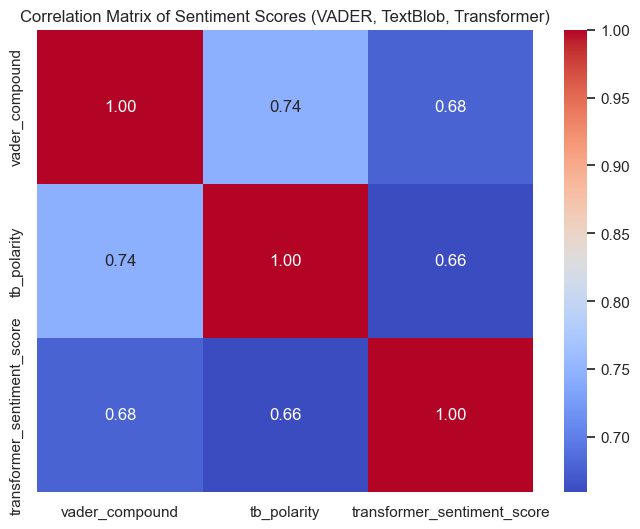

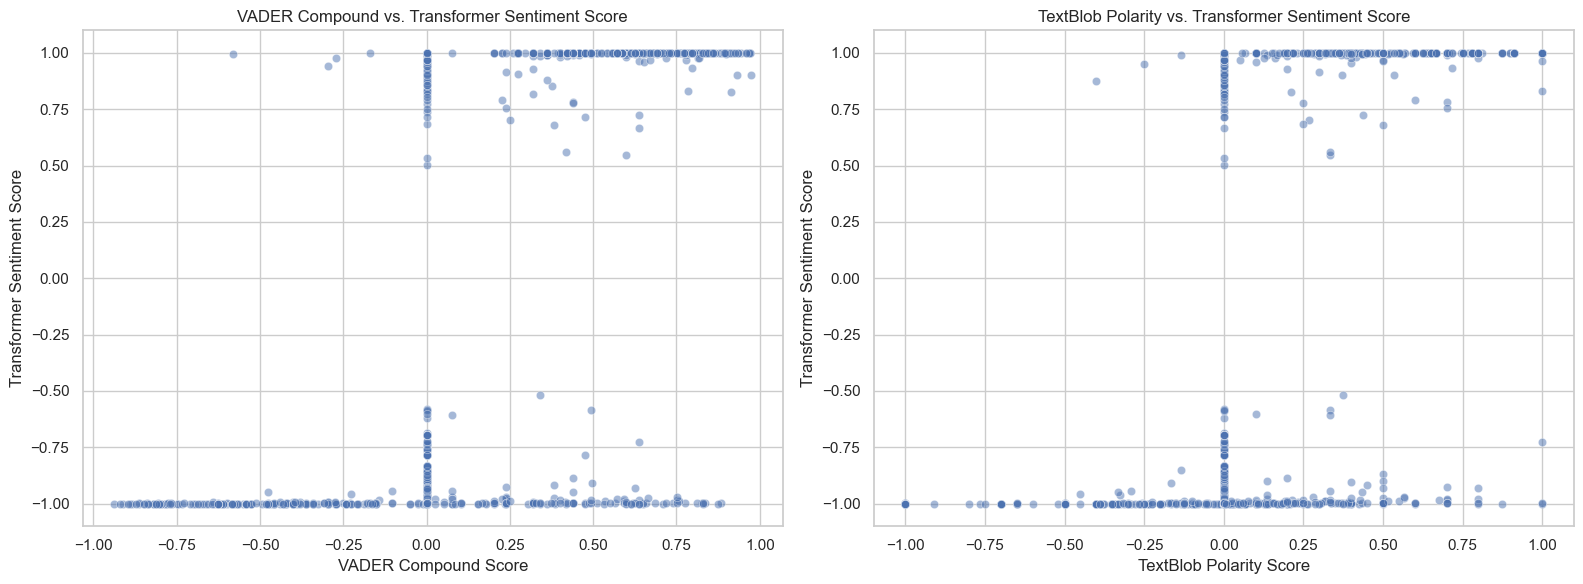

In [36]:
# Cell 11.1: Visualizing Sentiment Score Correlation

# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'tb_polarity', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, TextBlob, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5, ax=axes[0])
    axes[0].set_title('VADER Compound vs. Transformer Sentiment Score')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_ylabel('Transformer Sentiment Score')

    sns.scatterplot(data=df_clean, x='tb_polarity', y='transformer_sentiment_score', alpha=0.5, ax=axes[1])
    axes[1].set_title('TextBlob Polarity vs. Transformer Sentiment Score')
    axes[1].set_xlabel('TextBlob Polarity Score')
    axes[1].set_ylabel('Transformer Sentiment Score')

    plt.tight_layout()
    plt.show()

In [37]:
# Comparing Sentiment Distributions

if 'transformer_sentiment_label' not in df_clean.columns:
    print("Transformer sentiment labels not available for comparison.")
else:
    print("\n--- Sentiment Label Distributions ---")
    print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))
    print("\nTextBlob Polarity Distribution (thresholded at +/-0.05):\n")
    def get_tb_label(s):
        return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
    print(df_clean['tb_polarity'].apply(get_tb_label).value_counts(normalize=True).round(2))
    print("\nTransformer Distribution:\n", df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))


--- Sentiment Label Distributions ---
VADER Distribution:
 sentiment
positive    0.60
neutral     0.26
negative    0.14
Name: proportion, dtype: float64

TextBlob Polarity Distribution (thresholded at +/-0.05):

tb_polarity
positive    0.61
neutral     0.29
negative    0.10
Name: proportion, dtype: float64

Transformer Distribution:
 transformer_sentiment_label
POSITIVE    0.61
NEGATIVE    0.39
Name: proportion, dtype: float64


## 3. Aggregating Sentiment Scores by App and Star Rating

rating,1,2,3,4,5
app,,,,,
BOA,-0.170079,0.055212,0.116389,0.309881,0.352754
CBE,-0.032788,0.185923,-0.050770,0.197252,0.391663
Dashen,-0.150357,0.052956,0.273067,0.375218,0.441407


rating,1,2,3,4,5
app,,,,,
BOA,-0.100287,0.112909,0.216715,0.399144,0.474641
CBE,0.017355,0.203722,0.176217,0.288793,0.502876
Dashen,-0.166249,0.162729,0.184879,0.415076,0.470003


rating,1,2,3,4,5
app,,,,,
BOA,-0.828122,-0.563670,-0.238850,0.071962,0.635631
CBE,-0.578696,-0.691198,-0.382954,-0.063361,0.705113
Dashen,-0.771980,-0.547338,-0.542542,0.329649,0.738685


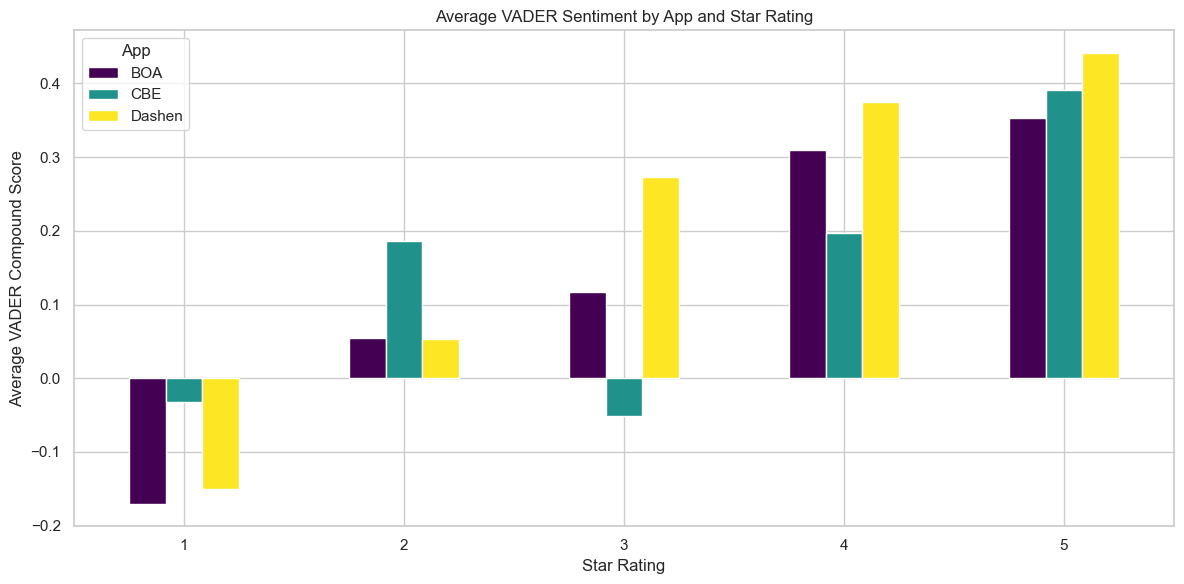

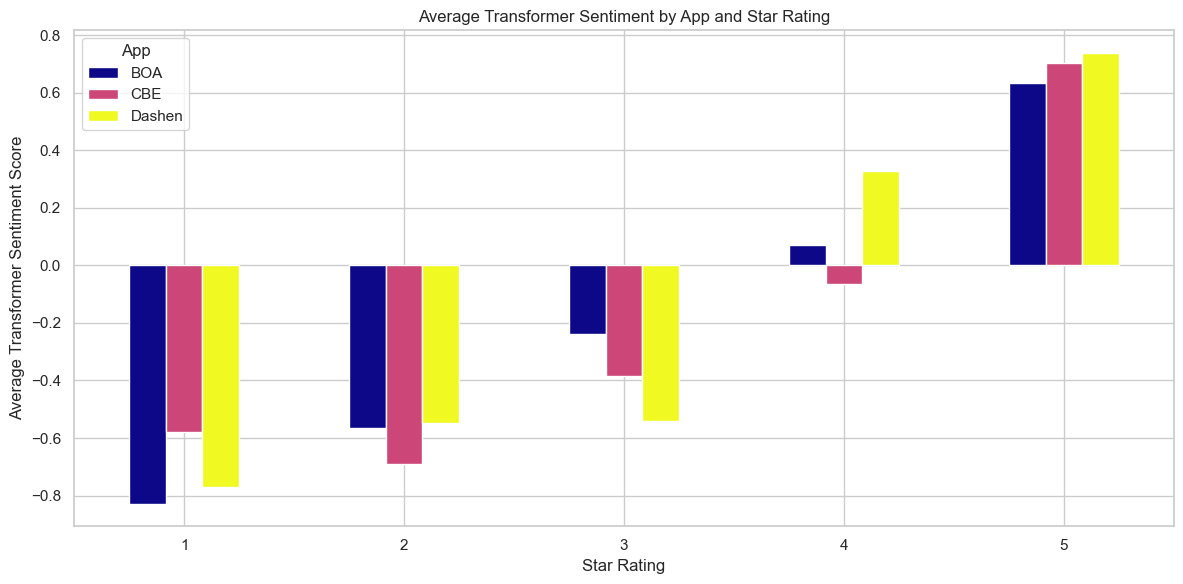

In [38]:
# Aggregate VADER sentiment scores by app and star rating
vader_agg_sentiment = df_clean.groupby(['app', 'rating'])['vader_compound'].mean().unstack()
display(vader_agg_sentiment)

# Aggregate TextBlob polarity scores by app and star rating
tb_agg_sentiment = df_clean.groupby(['app', 'rating'])['tb_polarity'].mean().unstack()
display(tb_agg_sentiment)

# Aggregate Transformer sentiment scores by app and star rating
transformer_agg_sentiment = df_clean.groupby(['app', 'rating'])['transformer_sentiment_score'].mean().unstack()
display(transformer_agg_sentiment)

# Visualize VADER sentiment by app and rating
vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average VADER Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Compound Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

# Visualize Transformer sentiment by app and rating
transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Average Transformer Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Transformer Sentiment Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

## 4.Thematic Analysis

## 5. Advanced Theme Analysis with TF-IDF and Topic Modeling

### Theme Extraction Methodology

**Approach:**
1. **TF-IDF Extraction**: Use TF-IDF to identify significant keywords and bigrams (2-word phrases) that appear frequently in reviews but are rare across the corpus
2. **Per-Bank Analysis**: Extract themes separately for each bank (BOA, CBE, Dashen) to capture bank-specific issues
3. **Theme Grouping**: Group related keywords into 3-5 business-relevant themes per bank based on semantic similarity
4. **Topic Modeling**: Use NMF (Non-negative Matrix Factorization) as an additional method for automated theme discovery

**Rationale:**
- TF-IDF helps identify distinctive terms that characterize each bank's user feedback
- Per-bank analysis reveals unique pain points and strengths for each institution
- Manual grouping ensures themes map to actionable business categories
- NMF provides data-driven validation of the manually identified themes

In [39]:
# TF-IDF for Keyword and N-gram Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_tfidf_keywords(texts, ngram_range=(1, 2), top_n=20):
    """Extract top keywords and bigrams using TF-IDF"""
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=1000,
        stop_words='english',
        min_df=2,
        max_df=0.8
    )
    
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    
    # Get mean TF-IDF score for each term across all documents
    mean_scores = tfidf_matrix.mean(axis=0).A1
    
    # Create dataframe of terms and scores
    term_scores = pd.DataFrame({
        'term': feature_names,
        'score': mean_scores
    }).sort_values('score', ascending=False)
    
    return term_scores.head(top_n)

# Extract keywords for each bank
bank_keywords = {}
for bank in df_clean['app'].unique():
    bank_reviews = df_clean[df_clean['app'] == bank]['clean_text']
    keywords = extract_tfidf_keywords(bank_reviews, ngram_range=(1, 2), top_n=30)
    bank_keywords[bank] = keywords
    print(f"\n{bank} - Top Keywords:")
    print(keywords.head(15).to_string(index=False))


BOA - Top Keywords:
    term    score
    good 0.160793
     app 0.090909
    best 0.048632
    nice 0.041022
     boa 0.031475
    work 0.027124
    bank 0.026151
 working 0.023131
  mobile 0.017338
    fast 0.017197
 banking 0.017146
good app 0.016360
     use 0.016085
   worst 0.015950
    like 0.015308

CBE - Top Keywords:
       term    score
       good 0.182496
        app 0.076636
       nice 0.059789
       best 0.053716
        cbe 0.025704
       bank 0.021483
       like 0.020180
    working 0.020061
   nice app 0.018998
    service 0.018462
        use 0.018163
     update 0.017644
  excellent 0.017216
       easy 0.016651
application 0.016311

Dashen - Top Keywords:
     term    score
     good 0.115779
      app 0.086239
     nice 0.050496
     best 0.046596
     bank 0.039396
   dashen 0.028659
     easy 0.021093
    great 0.020742
 nice app 0.020131
    super 0.019981
      use 0.019403
     fast 0.019246
excellent 0.016614
 best app 0.015343
  banking 0.014931


In [40]:
# Per-Bank Theme Grouping (3-5 themes per bank)
BANK_THEMES = {
    'BOA': {
        'Account Access': ['login', 'otp', 'password', 'account', 'sign', 'verify', 'access'],
        'App Performance': ['slow', 'crash', 'freeze', 'bug', 'error', 'stuck', 'failed', 'loading'],
        'Transaction Issues': ['transfer', 'payment', 'bill', 'transaction', 'money', 'send', 'receive'],
        'User Experience': ['ui', 'interface', 'design', 'easy', 'navigation', 'clean', 'user friendly']
    },
    'CBE': {
        'Account Access': ['login', 'otp', 'password', 'account', 'sign', 'verify'],
        'Transaction Performance': ['slow', 'transfer', 'payment', 'transaction', 'delay', 'processing'],
        'UI & Design': ['ui', 'interface', 'design', 'navigation', 'layout', 'update'],
        'Customer Support': ['support', 'service', 'help', 'response', 'contact']
    },
    'Dashen': {
        'Account Access': ['login', 'otp', 'password', 'account', 'sign', 'register'],
        'Transaction Issues': ['transfer', 'payment', 'bill', 'transaction', 'failed', 'error'],
        'App Stability': ['crash', 'freeze', 'bug', 'slow', 'stuck', 'loading', 'performance'],
        'Feature Requests': ['feature', 'add', 'need', 'want', 'improve', 'update']
    }
}

def assign_bank_theme(text, bank):
    """Assign theme based on bank-specific keyword mapping"""
    text = str(text).lower()
    bank_themes = BANK_THEMES.get(bank, {})
    
    for theme, keywords in bank_themes.items():
        if any(keyword in text for keyword in keywords):
            return theme
    return 'Other'

# Apply bank-specific theme assignment
df_clean['bank_theme'] = df_clean.apply(lambda row: assign_bank_theme(row['clean_text'], row['app']), axis=1)

print("Theme distribution by bank:")
for bank in df_clean['app'].unique():
    bank_df = df_clean[df_clean['app'] == bank]
    print(f"\n{bank}:")
    print(bank_df['bank_theme'].value_counts())

Theme distribution by bank:

BOA:
bank_theme
Other                 407
App Performance        36
Account Access         28
Transaction Issues     13
User Experience         8
Name: count, dtype: int64

CBE:
bank_theme
Other                      396
Transaction Performance     38
UI & Design                 20
Customer Support            17
Account Access               6
Name: count, dtype: int64

Dashen:
bank_theme
Other                 379
Feature Requests       41
Account Access         33
Transaction Issues     27
App Stability           9
Name: count, dtype: int64


In [41]:
# NMF Topic Modeling for Automated Theme Discovery
from sklearn.decomposition import NMF

def perform_nmf_topic_modeling(texts, n_topics=4, n_top_words=10):
    """Perform NMF topic modeling to discover latent themes"""
    vectorizer = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        stop_words='english',
        min_df=2,
        max_df=0.8
    )
    
    tfidf_matrix = vectorizer.fit_transform(texts)
    
    # Fit NMF model
    nmf_model = NMF(n_components=n_topics, random_state=42, max_iter=200)
    nmf_output = nmf_model.fit_transform(tfidf_matrix)
    
    # Extract top words for each topic
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    
    for topic_idx, topic in enumerate(nmf_model.components_):
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        topics.append(top_words)
    
    return topics, nmf_model, vectorizer

# Perform NMF for each bank
bank_topics = {}
for bank in df_clean['app'].unique():
    bank_reviews = df_clean[df_clean['app'] == bank]['clean_text']
    topics, model, vectorizer = perform_nmf_topic_modeling(bank_reviews, n_topics=4, n_top_words=8)
    bank_topics[bank] = {'topics': topics, 'model': model, 'vectorizer': vectorizer}
    
    print(f"\n{bank} - NMF Discovered Topics:")
    for i, topic_words in enumerate(topics):
        print(f"  Topic {i+1}: {', '.join(topic_words)}")


BOA - NMF Discovered Topics:
  Topic 1: good, good app, application, good service, update, service, work, good application
  Topic 2: app, good app, worst, boa, best app, mobile, bank, worst app
  Topic 3: nice, nice app, banking, application, use, service, mobile banking, mobile
  Topic 4: best, best app, ethiopia, best best, best bank, bank, boa, apps

CBE - NMF Discovered Topics:
  Topic 1: good, good app, good service, good application, service, application, job, good job
  Topic 2: nice, nice app, bank, perfect, thanks, charge, fast easy, crash
  Topic 3: best, best app, like, experience, secured, best bank, app financial, ethiopia
  Topic 4: app, nice app, good app, best app, cbe, excellent, update, like

Dashen - NMF Discovered Topics:
  Topic 1: good, good app, good fast, app good, service, load, experience, job
  Topic 2: nice, nice app, app, financial, thank, week, app seen, seen
  Topic 3: best, best app, ethiopia, application, fast, version, option, ussd
  Topic 4: app, ba

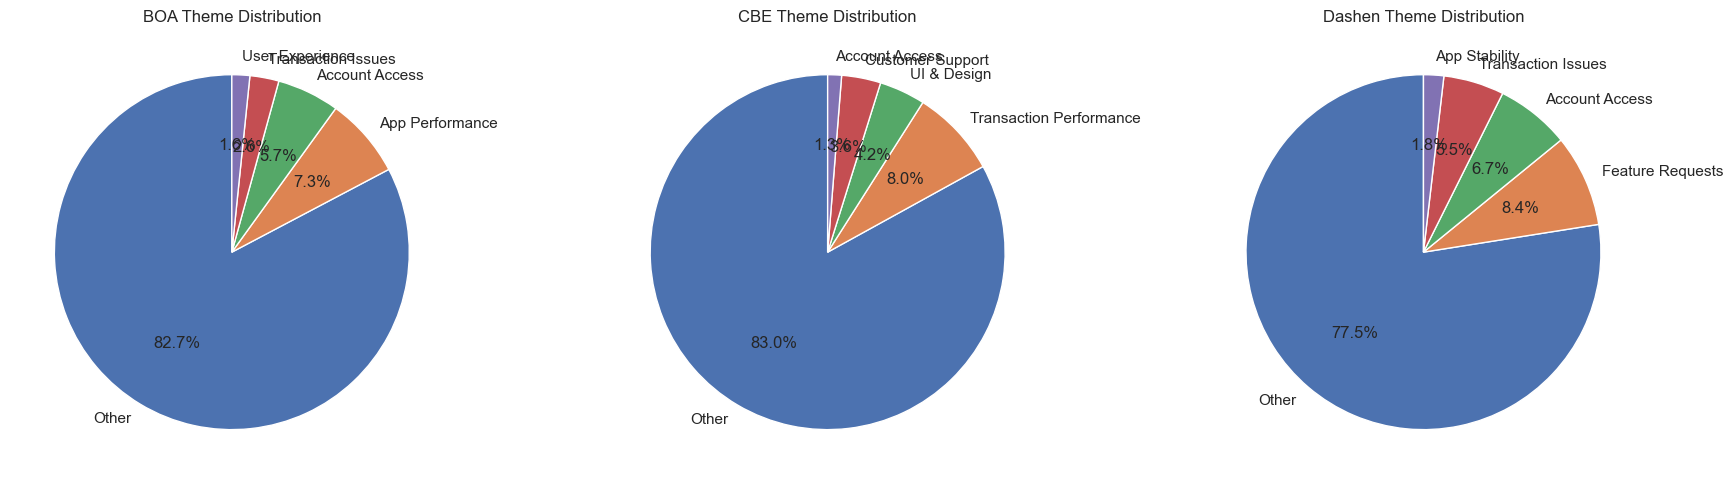


Average transformer_sentiment_score by Bank and Theme:
bank_theme  Account Access  App Performance  App Stability  Customer Support  \
app                                                                            
BOA              -0.707804        -0.989797            NaN               NaN   
CBE              -0.999272              NaN            NaN          0.871854   
Dashen           -0.391986              NaN      -0.555203               NaN   

bank_theme  Feature Requests     Other  Transaction Issues  \
app                                                          
BOA                      NaN  0.265294           -0.688352   
CBE                      NaN  0.448024                 NaN   
Dashen             -0.286578  0.477087           -0.340803   

bank_theme  Transaction Performance  UI & Design  User Experience  
app                                                                
BOA                             NaN          NaN        -0.520603  
CBE                       -0

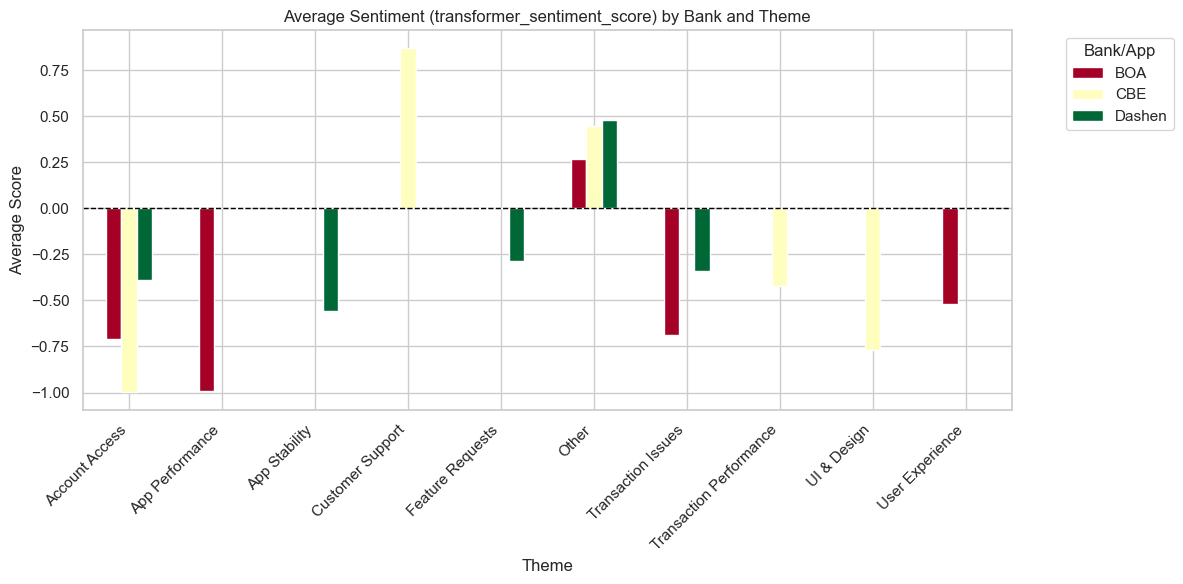

In [42]:

# 1. VISUALIZE THEME DISTRIBUTION BY BANK
# Detect unique banks/apps in your data
banks = df_clean['app'].unique() if 'app' in df_clean.columns else [stock for stock in prepared_data.keys()]
fig, axes = plt.subplots(1, len(banks), figsize=(18, 5))
if len(banks) == 1: axes = [axes] # Handle single bank case

for idx, bank in enumerate(banks):
    # Filter data for specific bank
    bank_col = 'app' if 'app' in df_clean.columns else 'stock'
    bank_df = df_clean[df_clean[bank_col] == bank]
    
    # Use 'theme' or 'bank_theme' depending on what was created in Cell 12
    theme_col = 'theme' if 'theme' in bank_df.columns else 'bank_theme'
    
    if theme_col in bank_df.columns:
        theme_counts = bank_df[theme_col].value_counts()
        axes[idx].pie(theme_counts.values, labels=theme_counts.index, autopct='%1.1f%%', startangle=90)
        axes[idx].set_title(f'{bank} Theme Distribution')
    else:
        axes[idx].set_title(f'{bank}: No Themes Found')

plt.tight_layout()
plt.show()

# 2. THEME SENTIMENT ANALYSIS
# Identify which sentiment score to use (Transformer fallback to VADER)
sent_score_col = None
for col in ['transformer_sentiment_score', 'vader_compound']:
    if col in df_clean.columns:
        sent_score_col = col
        break

if sent_score_col:
    # Use the identified bank and theme columns
    bank_col = 'app' if 'app' in df_clean.columns else 'stock'
    theme_col = 'theme' if 'theme' in df_clean.columns else 'bank_theme'
    
    theme_sentiment = df_clean.groupby([bank_col, theme_col])[sent_score_col].mean().unstack()
    
    print(f"\nAverage {sent_score_col} by Bank and Theme:")
    print(theme_sentiment)

    # Plotting
    theme_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='RdYlGn')
    plt.title(f'Average Sentiment ({sent_score_col}) by Bank and Theme')
    plt.xlabel('Theme')
    plt.ylabel('Average Score')
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Bank/App', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Error: No sentiment score column found (Run VADER or Transformer cell first).")

In [70]:
# Save results as CSV with specified columns (updated with bank_theme)
import os
df_clean['review_id'] = df_clean.index.astype(str)

cols_to_save = [
    'review_id', 'review', 'rating', 
    'transformer_sentiment_label', 
    'transformer_sentiment_score', 
    'bank_theme'
]

# 3. Create the output dataframe
output_df = df_clean[cols_to_save].copy()

# 4. Rename them for the database
output_df = output_df.rename(columns={
    'review': 'review_text',
    'transformer_sentiment_label': 'sentiment_label',
    'transformer_sentiment_score': 'sentiment_score',
    'bank_theme': 'identified_theme'
})
# Create output dataframe with required columns (using bank_theme instead of theme)
output_df = df_clean[['review_id', 'review','bank_id', 'rating','transformer_sentiment_label', 'transformer_sentiment_score', 'bank_theme']].copy()

# Save to CSV
os.makedirs('data/processed_with_sentiment', exist_ok=True)
output_path = 'data/processed_with_sentiment/semantic_analysis_results.csv'
output_df.to_csv(output_path, index=False)

print(f"Saved results to: {output_path}")
print(f"Total records: {len(output_df)}")
print(f"\nTheme distribution in output:")
print(output_df['identified_theme'].value_counts())
output_df.head(10)

KeyError: "['transformer_sentiment_label', 'transformer_sentiment_score', 'bank_theme'] not in index"

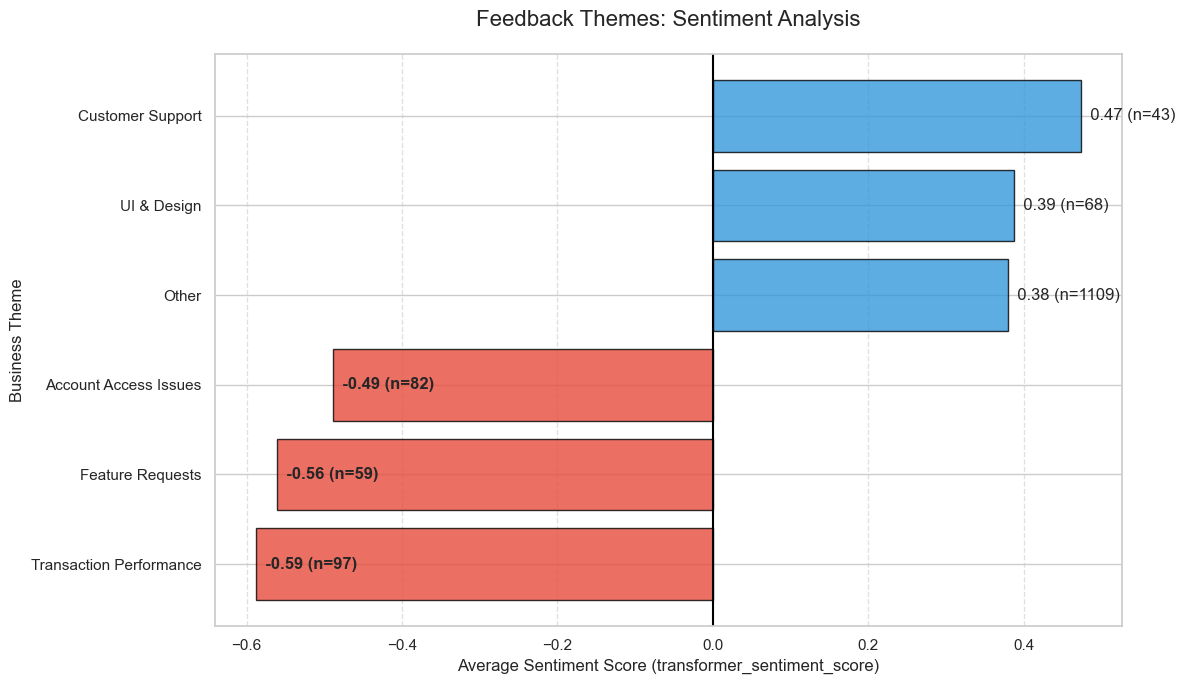

In [ ]:

# 1. Define Business-Relevant Themes
THEME_MAP = {
    'Account Access Issues': ['login', 'otp', 'password', 'account', 'verify', 'sign', 'access', 'locked'],
    'Transaction Performance': ['transfer', 'payment', 'bill', 'slow', 'pending', 'failed', 'transaction', 'money'],
    'UI & Design': ['ui', 'interface', 'clean', 'easy', 'navigation', 'design', 'look', 'graphics'],
    'Customer Support': ['support', 'help', 'service', 'chat', 'agent', 'contact', 'call', 'reply'],
    'Feature Requests': ['add', 'feature', 'suggest', 'update', 'wish', 'want', 'missing', 'improve']
}

def get_theme(txt):
    if not isinstance(txt, str):
        return 'Other'
    
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        # Using any() allows us to catch the first theme that matches a keyword
        if any(w in txt for w in keywords): 
            return theme
    return 'Other'

# 2. Apply and Group Data
df_clean['theme'] = df_clean['review'].apply(get_theme)

# Safety check for sentiment column (prioritizing Transformer score if available)
sent_col = 'transformer_sentiment_score' if 'transformer_sentiment_score' in df_clean.columns else 'vader_compound'

# Aggregate results
theme_analysis = df_clean.groupby('theme')[sent_col].agg(['mean', 'count']).sort_values('mean')

# 3. Enhanced Visualization
plt.figure(figsize=(12, 7))

# Set color logic: Red for pain points (negative), Blue for drivers (positive)
colors = ['#e74c3c' if x < 0 else '#3498db' for x in theme_analysis['mean']]

bars = plt.barh(theme_analysis.index, theme_analysis['mean'], color=colors, edgecolor='black', alpha=0.8)

# Add data labels for sample size and score
for i, (name, row) in enumerate(theme_analysis.iterrows()):
    plt.text(row['mean'], i, f"  {row['mean']:.2f} (n={int(row['count'])})", 
             va='center', fontweight='bold' if row['mean'] < -0.3 else 'normal')

plt.axvline(0, color='black', linewidth=1.5, linestyle='-')
plt.title('Feedback Themes: Sentiment Analysis', fontsize=16, pad=20)
plt.xlabel(f'Average Sentiment Score ({sent_col})', fontsize=12)
plt.ylabel('Business Theme', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##  N-gram Analysis (Context Discovery)

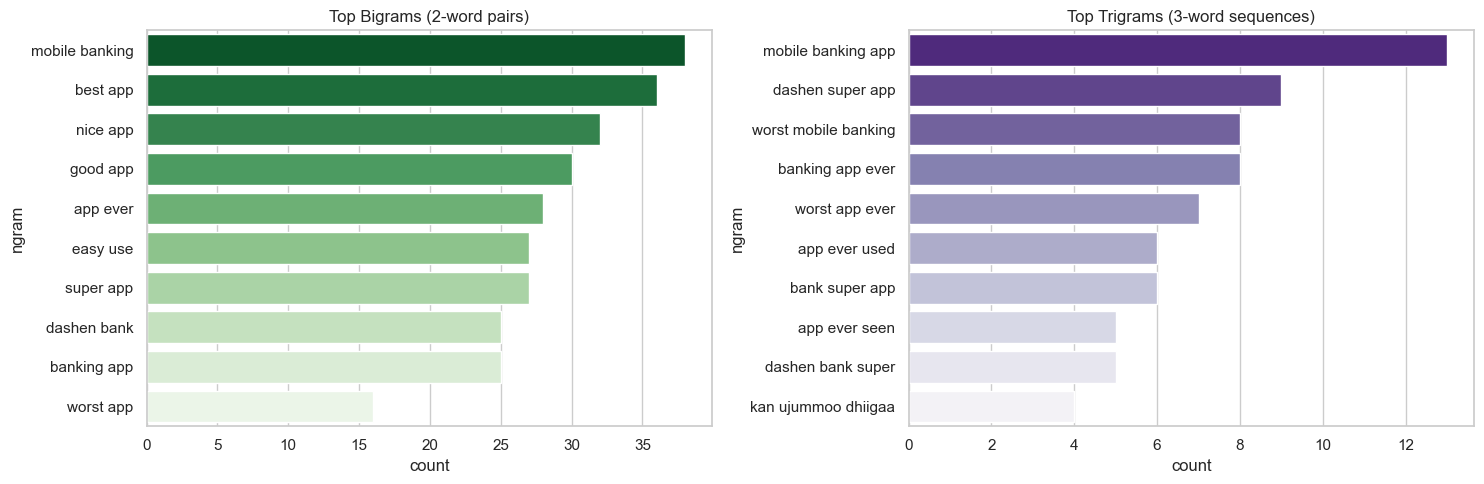

In [ ]:

def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

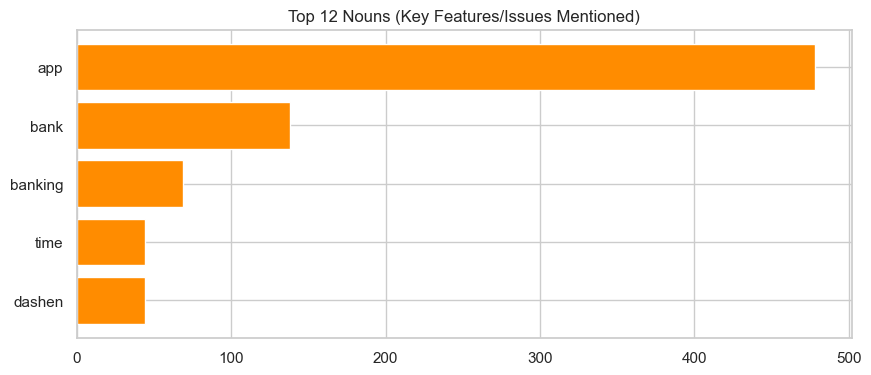

In [ ]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(5)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## zero-shot classification 

In [ ]:
from transformers import pipeline

# 1. Initialize the classifier (using a lightweight model for speed)
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# 2. Define the candidate labels (your themes)
candidate_labels = ["Account Access", "Transaction Performance", "UI & Design", "Customer Support", "Feature Request"]

def discover_theme_zeroshot(text):
    if not isinstance(text, str) or len(text) < 10:
        return "Other"
    
    # Get the top prediction
    result = classifier(text, candidate_labels)
    # The first label in 'labels' has the highest score
    return result['labels'][0]

# Note: This is computationally expensive. Run it on a sample first!
# sample_df = df_clean.sample(50)
# sample_df['ai_theme'] = sample_df['review'].apply(discover_theme_zeroshot)

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 850.21it/s]


# Pipeline

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def modular_nlp_pipeline(text):
    # Safety check for non-string data
    if not isinstance(text, str):
        return ""
    
    # Cleaning: Remove special characters and lowercase
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())

    # Tokenization: Break into individual words
    tokens = word_tokenize(text)

    # Lemmatization & Stop-word removal
    # lemmatize() reduces words to their root (e.g., "running" -> "run")
    processed = [
        lemmatizer.lemmatize(t) 
        for t in tokens 
        if t not in stop_words and len(t) > 2
    ]
    
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
# Using a .copy() avoids "SettingWithCopyWarning" later
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()

print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 1389


In [71]:
# 1. Add review_id column
df_clean['review_id'] = df_clean.index.astype(str)

# 2. Define the columns we WANT (Updated to include bank_id)
potential_cols = {
    'review_id': 'review_id',
    'bank_id': 'bank_id',             # <--- CRITICAL: Added this
    'review': 'review_text',
    'transformer_sentiment_label': 'sentiment_label',
    'transformer_sentiment_score': 'sentiment_score',
    'bank_theme': 'identified_theme'   # Using the name from your cleaning step
}

# Find which of these columns actually exist in df_clean
existing_cols = {old: new for old, new in potential_cols.items() if old in df_clean.columns}

if 'bank_id' not in existing_cols:
    print("Warning: bank_id not found! Check your ID mapping step.")

if not existing_cols:
    print("Error: None of the required columns were found in df_clean!")
else:
    # Create output_df using only what we found
    output_df = df_clean[list(existing_cols.keys())].copy()
    
    # Rename them to your desired business names
    output_df = output_df.rename(columns=existing_cols)

    # 3. Save to CSV
    os.makedirs('data/processed_with_sentiment', exist_ok=True)
    output_path = 'data/processed_with_sentiment/semantic_analysis_results.csv'
    output_df.to_csv(output_path, index=False)

    print(f"Saved results to: {output_path}")
    print(f"Total records: {len(output_df)}")
    print(f"Columns exported: {list(output_df.columns)}")
    display(output_df.head(10))

Saved results to: data/processed_with_sentiment/semantic_analysis_results.csv
Total records: 1458
Columns exported: ['review_id', 'bank_id', 'review_text']


,review_id,bank_id,review_text
0,0,1,Tilku
1,1,1,the transaction is not working???? fix it
2,2,1,sometimes The App Is not goibg through
3,3,1,"The worst app, also bank am begging for my own..."
4,4,1,was Good 🙏
5,5,1,cool
6,6,1,Its Good
7,7,1,good
8,8,1,it's very good app
9,9,1,this app is good but the speed of app is very ...


In [ ]:
# Cell: Modular Preprocessing and Export
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os
import re

def process_text_modular(text, apply_lemmatization=True):
    """
    Handles tokenization, stop-word removal, and optional lemmatization.
    """
    if pd.isna(text):
        return ""
    
    # Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Stop-word removal
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # Optional Lemmatization
    if apply_lemmatization:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        
    return " ".join(tokens)

# Apply the preprocessing
df_clean['processed_text'] = df_clean['review'].apply(lambda x: process_text_modular(x, apply_lemmatization=True))

# Prepare the final dataframe with requested columns
# review_id, review_text, sentiment_label, sentiment_score, identified_theme
df_export = pd.DataFrame()

# Assuming review_id can be generated if not present
if 'review_id' in df_clean.columns:
    df_export['review_id'] = df_clean['review_id']
else:
    df_export['review_id'] = df_clean.index + 1
    
df_export['review_text'] = df_clean['review']

if 'sentiment' in df_clean.columns:
    df_export['sentiment_label'] = df_clean['sentiment']
else:
    df_export['sentiment_label'] = 'Neutral'
    
if 'vader_compound' in df_clean.columns:
    df_export['sentiment_score'] = df_clean['vader_compound']
else:
    df_export['sentiment_score'] = 0.0

# Using identified_theme if available, else 'General'
if 'theme' in df_clean.columns:
    df_export['identified_theme'] = df_clean['theme']
else:
    df_export['identified_theme'] = 'General'

# Save to CSV
output_csv = 'processed_reviews.csv'
df_export.to_csv(output_csv, index=False)
print(f"Results saved to {output_csv}")


Results saved to processed_reviews.csv
